In [1]:
import os
os.environ["PATH"] = "/data/apps/extern/spack_on/gcc/9.3.0/texlive/20220321-oikenzl6gekq5lsohdm6jnnuj276s2ba/bin/x86_64-linux:" + os.environ.get("PATH", "")

import sys
from pathlib import Path

this_notebook = Path().resolve()

project_root = this_notebook.parents[0]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## Module imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm, SymLogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

#import Zeus
import zeus21

#set up the CLASS cosmology
from classy import Class
import mcfit
from scipy.interpolate import interp1d
from tqdm import tqdm
# from scipy.integrate import simps as simpson
from scipy.integrate import simpson
from scipy.special import i0

## Get high-res $\rho$'s using memory-friendly method

In [4]:
UserParams = zeus21.User_Parameters(precisionboost=1.2)

# cosmo inputs from table 2 last column of 1807.06209, as 21cmFAST
ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

CosmoParams_input = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False
    )

ClassCosmoVCB = Class()
ClassCosmoVCB.set({'omega_b': CosmoParams_input.omegab,
                   'omega_cdm': CosmoParams_input.omegac,
                   'h': CosmoParams_input.h_fid,
                   'A_s': CosmoParams_input.As,
                   'n_s': CosmoParams_input.ns,
                   'tau_reio': CosmoParams_input.tau_fid})
ClassCosmoVCB.set({'output':'vTk'})
ClassCosmoVCB.set({'P_k_max_1/Mpc':50.0, 'z_max_pk':12000})
ClassCosmoVCB.set({'gauge':'newtonian'})
ClassCosmoVCB.compute()

# Cosmo_Parameters = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input, ClassyCosmo) 

In [5]:
from scipy.interpolate import interp1d

rlist = np.geomspace(0.1, 3000, 300)
klist, _dummy_ = mcfit.xi2P(rlist, l=0, lowring=True)(0*rlist, extrap=False)

# kmask = (klist >= 1e-3) & (klist <= 1.0)
# klist_trim = klist[kmask]
# Plist_trim = Plist[kmask]

z_drag = ClassCosmoVCB.get_current_derived_parameters(['z_d'])['z_d']
velTransFunc = ClassCosmoVCB.get_transfer(z_drag)

c_kms = 299792.458
k_vcb = velTransFunc['k (h/Mpc)'] * CosmoParams_input.h_fid
theta_b = velTransFunc['t_b']
theta_c = velTransFunc['t_cdm']
interp_func_theta_b = interp1d(k_vcb, theta_b, kind='cubic', fill_value="extrapolate")
interp_func_theta_c = interp1d(k_vcb, theta_c, kind='cubic', fill_value="extrapolate")
theta_b_dense = interp_func_theta_b(klist)
theta_c_dense = interp_func_theta_c(klist)

P_vcb = CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) * (theta_b_dense - theta_c_dense)**2/klist**2 * 2 * np.pi**2 / klist**3
sigma_vcb = np.sqrt(np.trapz(CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) / klist * (theta_b_dense - theta_c_dense)**2/klist**2, klist)) * c_kms


def Window(k,R):
        x = k * R
        return 3.0/x**2 * (np.sin(x)/x - np.cos(x))

/var/folders/b4/hg5l8r9915b4cr385qb8sfdw0000gn/T/ipykernel_14080/456788667.py:23: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  sigma_vcb = np.sqrt(np.trapz(CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) / klist * (theta_b_dense - theta_c_dense)**2/klist**2, klist)) * c_kms


In [6]:
# Original implementation (causes OOM)
# lengthRarray = len(rlist)
#
# windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
# windowR2 = Window(klist.reshape(1, lengthRarray,1), rlist.reshape(1, 1, lengthRarray))
#
# psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2
# psi_integrand_base = psi_integrand_base[:, :, np.newaxis, :]
#
# psi_prefactor = 1 / (3 * (sigma_vcb/c_kms)**2)
#
# r_transpose = np.transpose([rlist])
# j0bessel = lambda x: np.sin(x)/x
# j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x)/x - 3*np.cos(x)/x**2
#
# psi0 = 1 * psi_prefactor * np.trapz(psi_integrand_base * j0bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                     klist, axis = -1)
# psi2 = -2 * psi_prefactor * np.trapz(psi_integrand_base * j2bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                         klist, axis = -1)
#
# xi_para_RR_CF = psi0 + psi2
# xi_perp_RR_CF = psi0 - 0.5 * psi2
#
# # Normalize them
# xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
# xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

import gc

lengthRarray = len(rlist)

windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
windowR2 = Window(klist.reshape(1, lengthRarray, 1), rlist.reshape(1, 1, lengthRarray))
psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2

psi_prefactor = 1 / (3 * (sigma_vcb / c_kms)**2)

r_transpose = np.transpose([rlist])
j0bessel = lambda x: np.sin(x) / x
j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2

# Trapezoid weights so each integration can be done as a weighted contraction.
dk = np.diff(klist)
trapz_w = np.empty_like(klist)
trapz_w[0] = 0.5 * dk[0]
trapz_w[-1] = 0.5 * dk[-1]
trapz_w[1:-1] = 0.5 * (klist[2:] - klist[:-2])

j0_grid = j0bessel(klist * r_transpose)
j2_grid = j2bessel(klist * r_transpose)

# Allocate only the final arrays to reduce peak memory.
xi_para_RR_CF = np.empty((lengthRarray, lengthRarray, lengthRarray), dtype=np.float64)
xi_perp_RR_CF = np.empty_like(xi_para_RR_CF)

for ir in range(lengthRarray):
    w0 = j0_grid[ir] * trapz_w
    w2 = j2_grid[ir] * trapz_w
    integ0 = psi_prefactor * np.tensordot(psi_integrand_base, w0, axes=([-1], [0]))
    integ2 = -2 * psi_prefactor * np.tensordot(psi_integrand_base, w2, axes=([-1], [0]))
    xi_para_RR_CF[:, :, ir] = integ0 + integ2
    xi_perp_RR_CF[:, :, ir] = integ0 - 0.5 * integ2

# Normalize them
xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

# Drop large temporaries before moving to later cells to avoid kernel OOM.
del windowR1, windowR2, psi_integrand_base, dk, trapz_w, j0_grid, j2_grid
gc.collect()

481

### 4 $\rho$ plot

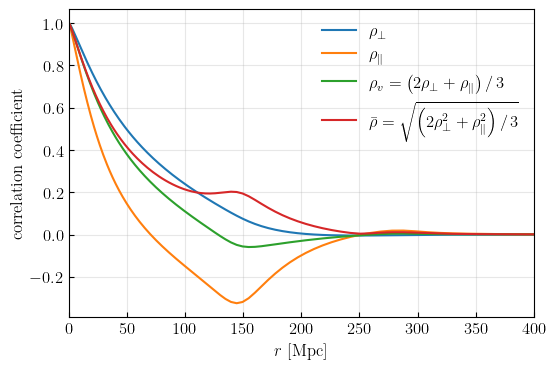

In [39]:
R1_choose = 0
R2_choose = 0

rho_para = xi_para_RR_CF[R1_choose, R2_choose, :]
rho_perp = xi_perp_RR_CF[R1_choose, R2_choose, :]
rho_orig = np.sqrt((2 * xi_perp_RR_CF[R1_choose, R2_choose, :]**2 + \
                   xi_para_RR_CF[R1_choose, R2_choose, :]**2) / 3)
rho_iso = (2 * rho_perp + rho_para) / 3

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(rlist, rho_perp, label=r'$\rho_{\perp}$')
ax.plot(rlist, rho_para, label=r'$\rho_{\parallel}$')
ax.plot(rlist, rho_iso, label=r'$\rho_v=\left(2\rho_\perp + \rho_\parallel\right)/\,3$')
ax.plot(rlist, rho_orig, label=r'$\bar\rho=\sqrt{\left(2\rho_{\perp}^2 + \rho_{\parallel}^2\right)/\,3}$')

ax.set_xlim(0, 400)
ax.set_xlabel(r'$r$ [Mpc]')
ax.set_ylabel(r'correlation coefficient')
ax.legend(frameon=False)
ax.tick_params(axis='both', which='major', direction='in')
ax.grid(True, which='both', alpha=0.3)

## Use these $\rho$'s to compute $\xi_U$

In [40]:
# Real run values from xi_U_comparison.ipynb
lambda1 = 1.1819690031628485
lambda2 = 1.1819690031628485

rho_sq_corrected = (2 * rho_perp**2 + rho_para**2) / 3

lambda_term = 4 * lambda1 * lambda2 / (1 + 2 * lambda1) / (1 + 2 * lambda2)
xi_U_aniso = ((1 - lambda_term * rho_para**2) * (1 - lambda_term * rho_perp**2) ** 2) ** (-1/2) - 1
xi_U_corrected = (1 - lambda_term * rho_sq_corrected) ** (-3/2) - 1

xi_U_aniso_normalized = xi_U_aniso / xi_U_aniso.max()
xi_U_corrected_normalized = xi_U_corrected / xi_U_corrected.max()

## Get $\xi_U$ with native $\rho$ from Zeus

Run Zeus:

In [30]:
import zeus21

UserParams = zeus21.User_Parameters(precisionboost=1.2)

ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

In [31]:
CosmoParams_input_zeus = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False, CORRECTED_XI_ETA=False
    )
ClassyCosmo_zeus = zeus21.runclass(CosmoParams_input_zeus)

In [32]:
CosmoParams_zeus = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input_zeus, ClassyCosmo_zeus)
CorrFClass_zeus = zeus21.Correlations(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)
HMFintclass_zeus = zeus21.HMF_interpolator(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)
CorrFClass_zeus = zeus21.Correlations(UserParams, CosmoParams_zeus, ClassyCosmo_zeus)

In [33]:
### POP II quantities first

################################
### Model Parameters
astromodel = 0            # ASTRO MODEL: 0 for GALUMI-like, 1 for 21cmfast-like, default 0
accretion_model = 0       # ACCRETION MODEL: 0 for exponential, 1 for EPS, default EXP

################################
### SFR(Mh) Parameteres
alphastar = 0.5          # alphastar powerlaw index for low masses, default 0.5
betastar = -0.5           # betastar powerlaw index for high masses, default -0.5
epsstar = 10**-1.             # epsilonstar = fstar at Mc
Mc = 3e11                 # Pivot mass at which the power law cuts for model 0, default Mc = 3e11
dlog10epsstardz = 0.0     # dlog10epsilonstar/dz, default 0

################################
### Escape fraction parameters
fesc10 = 0.1              # fesc(M) parameter. Power law normalized (fesc10) at M=1e10 Msun with index alphaesc
alphaesc = 0.0
L40_xray = 10**0.5        # L40_xray: soft-band (E<2 keV) lum/SFR in Xrays in units of 10^40 erg/s/(Msun/yr)
E0_xray = 500.            # E0_xray: minimum energy in eV
alpha_xray = -1.0         # Xray SED power-law index
Emax_xray_norm=2000       # max energy in eV to normalize SED. Keep at 2000 eV normally

################################
### LyA parameters
Nalpha_lyA_II = 9690      # number of Pop II photons between LyA and Ly Cont. per baryon (from BL05)
Nalpha_lyA_III = 17900    # number of Pop III photons between LyA and Ly Cont. per baryon value of 17900 is from Klessen & Glover 2023 (2303.12500), table A2

################################
### MTURN Parameters: 
Mturn_fixed = None        # Mturn_fixed: None if use Matom(z) at each z, Some value if fixed Mturn
FLAG_MTURN_SHARP= False   # Mturn_sharp: False if regular exponential cutoff, True if sharp cutoff, active only if Mturn_fixed is on

################################
### UVLF Parameters
C0dust = 4.43             # DUST PARAMETERS FOR UVLFs
C1dust = 1.99
sigmaUV = 0.5             # stochasticity (gaussian rms) in the halo-galaxy connection P(MUV | Mh) - TODO: only used in UVLF not sfrd

################################
ZMIN = 10.0               # down to which z we compute the evolution



################################
# Pop III Quantities
alphastar_III = 0 
betastar_III = 0
fstar_III = 10**(-3.0)
Mc_III = 1e7
dlog10epsstardz_III = 0.0

fesc7_III = 10**(-1.35)
alphaesc_III = -0.3
L40_xray_III = 10**0.5
alpha_xray_III = -1.0


USE_POPIII = True
USE_LW_FEEDBACK = True

A_LW = 2.0
beta_LW = 0.6

A_vcb = 1.0
beta_vcb = 1.8


#set up your astro parameters too, here the peak of f*(Mh) as an example

AstroParams = zeus21.Astro_Parameters(UserParams,
                                      CosmoParams_zeus, 
                                      astromodel = astromodel, 
                                      accretion_model = accretion_model,
                                      
                                      alphastar = alphastar, 
                                      betastar = betastar, 
                                      epsstar = epsstar, 
                                      Mc = Mc, 
                                      dlog10epsstardz = dlog10epsstardz,
                                      
                                      fesc10 = fesc10, 
                                      alphaesc = alphaesc,
                                      L40_xray = L40_xray, 
                                      E0_xray = E0_xray, 
                                      alpha_xray = alpha_xray, 
                                      Emax_xray_norm = Emax_xray_norm, 
                                      
                                      Nalpha_lyA_II = Nalpha_lyA_II, 
                                      Nalpha_lyA_III = Nalpha_lyA_III,
                                      
                                      Mturn_fixed = Mturn_fixed, 
                                      FLAG_MTURN_SHARP = FLAG_MTURN_SHARP,

                                      C0dust = C0dust, 
                                      C1dust = C1dust,
                                      sigmaUV = sigmaUV,
                                     
                                     
                                      USE_POPIII = USE_POPIII, 
                                      USE_LW_FEEDBACK = USE_LW_FEEDBACK,

                                      alphastar_III = alphastar_III, 
                                      betastar_III = betastar_III,
                                      fstar_III = fstar_III,
                                      Mc_III = Mc_III,
                                      dlog10epsstardz_III = dlog10epsstardz_III,

                                      fesc7_III = fesc7_III,
                                      alphaesc_III = alphaesc_III,
                                      L40_xray_III = L40_xray_III,
                                      alpha_xray_III = alpha_xray_III,
                                               
                                      A_LW = A_LW,
                                      beta_LW = beta_LW,
                                      
                                      A_vcb = A_vcb,
                                      beta_vcb = beta_vcb
                                               )

# CoeffStructure = zeus21.get_T21_coefficients(UserParams, CosmoParams, ClassyCosmo, AstroParams, HMFintclass, zmin=ZMIN)
CoeffStructure_zeus = zeus21.get_T21_coefficients(UserParams, CosmoParams_zeus, ClassyCosmo_zeus, AstroParams, HMFintclass_zeus,
                                                    zmin=ZMIN)

In [34]:
xiEta_zeus = CorrFClass_zeus.xiEta_RR_CF # ~ rho^2, with mcfit
rho_sq_zeus = xiEta_zeus *3/2

xi_U_zeus = (1 - lambda_term * rho_sq_zeus) ** (-3/2) - 1
xi_U_zeus_normalized = xi_U_zeus / xi_U_zeus.max()

In [35]:
# Interpolate Zeus outputs from their native radius grid onto the high-res rlist grid.
r_zeus = np.asarray(CosmoParams_zeus._Rtabsmoo)

interp_xi_u_zeus = interp1d(
    r_zeus,
    xi_U_zeus_normalized,
    axis=-1,
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate',
)
xi_U_zeus_normalized_on_rlist = interp_xi_u_zeus(rlist)

interp_rho_sq_zeus = interp1d(
    r_zeus,
    rho_sq_zeus,
    axis=-1,
    kind='linear',
    bounds_error=False,
    fill_value='extrapolate',
)
rho_sq_zeus_on_rlist = interp_rho_sq_zeus(rlist)

### $\rho^2$ precise vs. Zeus plot

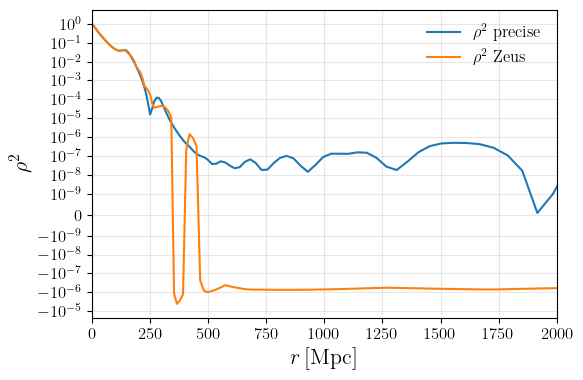

In [50]:
rho_sq_zeus_on_rlist_choose = rho_sq_zeus_on_rlist[R1_choose, R2_choose, :]

fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.plot(rlist, rho_sq_corrected, label=r'$\rho^2$ precise')
ax.plot(rlist, rho_sq_zeus_on_rlist_choose, label=r'$\rho^2$ Zeus')
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
ax.set_ylabel(r"$\rho^2$", fontsize=16)
ax.legend(frameon=False)
ax.set_yscale('symlog', linthresh=1e-9)
ax.set_xlim(0, 2000)
ax.grid(True, alpha=0.3)

## $\xi_U$ comparison

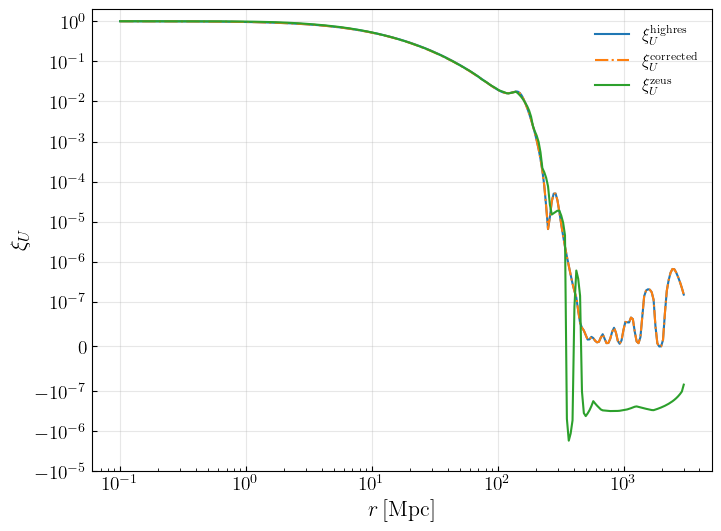

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rlist, xi_U_aniso_normalized[0, 0, :], label=r'$\xi_U^{\mathrm{highres}}$')
ax.plot(rlist, xi_U_corrected_normalized[0, 0, :], linestyle='-.', label=r"$\xi_U^{\mathrm{corrected}}$")
ax.plot(rlist, xi_U_zeus_normalized_on_rlist[0, 0, :], label=r"$\xi_U^{\mathrm{zeus}}$")
ax.set_ylim(-1e-5, 2)
ax.set_xscale("log")
ax.set_yscale('symlog', linthresh=1e-7)
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
ax.set_ylabel(r"$\xi_U$", fontsize=16)
ax.legend(frameon=False)
ax.tick_params(axis="both", which="both", direction="in", labelsize=14)
ax.grid(True, alpha=0.3)